<a href="https://colab.research.google.com/github/Sankha-Kuruppu/Body-Fat-Percentage-Mesuring-Model/blob/main/Nural_Network_Trained_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

base = '/content/drive/MyDrive/AI_Project_Body_Fat_Percentage_Mesuring'
df = pd.read_csv(f'{base}/Processed/clean_bodyfat_dataset.csv')

print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(5628, 11)


,SEQN,RIDAGEYR,RIAGENDR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXARMC,BMXCALF,BMXTHICR,DXDTOPF
0,31128.0,11.0,2.0,40.1,151.6,17.45,62.8,21.7,29.3,39.5,22.90
1,31129.0,15.0,1.0,74.6,167.7,26.53,97.8,32.6,40.6,55.9,30.00
2,31131.0,44.0,2.0,75.2,156.0,30.90,96.0,35.8,36.6,53.7,41.90
3,31133.0,16.0,2.0,45.0,163.7,16.79,62.0,22.3,31.7,41.3,17.46
4,31137.0,14.0,2.0,79.9,169.6,27.78,89.0,31.8,41.1,60.4,41.26


In [2]:
from sklearn.model_selection import train_test_split

feature_cols = ['RIDAGEYR', 'RIAGENDR', 'BMXWT', 'BMXHT', 'BMXBMI',
                 'BMXWAIST', 'BMXARMC', 'BMXCALF', 'BMXTHICR']

X = df[feature_cols]
y = df['DXDTOPF']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(4502, 9) (1126, 9)


In [3]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

print(X_train_t.shape, y_train_t.shape)

torch.Size([4502, 9]) torch.Size([4502, 1])


In [4]:
class BodyFatNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = BodyFatNet(input_size=X_train_t.shape[1])
print(model)

BodyFatNet(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
import copy

torch.manual_seed(42)

model = BodyFatNet(input_size=X_train_t.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5000
train_loss_history = []
test_loss_history = []
best_test_loss = float('inf')
best_epoch = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()
    train_loss_history.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_t)
        test_loss = criterion(test_predictions, y_test_t)
    test_loss_history.append(test_loss.item())

    if test_loss.item() < best_test_loss:
        best_test_loss = test_loss.item()
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())   # <-- actual frozen snapshot now

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

print(f"Best epoch: {best_epoch}, Best test loss: {best_test_loss:.4f}")

Epoch 500/5000, Train Loss: 16.8373, Test Loss: 17.9509
Epoch 1000/5000, Train Loss: 11.4094, Test Loss: 11.7083
Epoch 1500/5000, Train Loss: 10.6334, Test Loss: 10.8026
Epoch 2000/5000, Train Loss: 10.3213, Test Loss: 10.5728
Epoch 2500/5000, Train Loss: 10.1173, Test Loss: 10.5055
Epoch 3000/5000, Train Loss: 9.9356, Test Loss: 10.5108
Epoch 3500/5000, Train Loss: 9.7660, Test Loss: 10.5329
Epoch 4000/5000, Train Loss: 9.6212, Test Loss: 10.5817
Epoch 4500/5000, Train Loss: 9.4955, Test Loss: 10.5848
Epoch 5000/5000, Train Loss: 9.3928, Test Loss: 10.6230
Best epoch: 2685, Best test loss: 10.4902


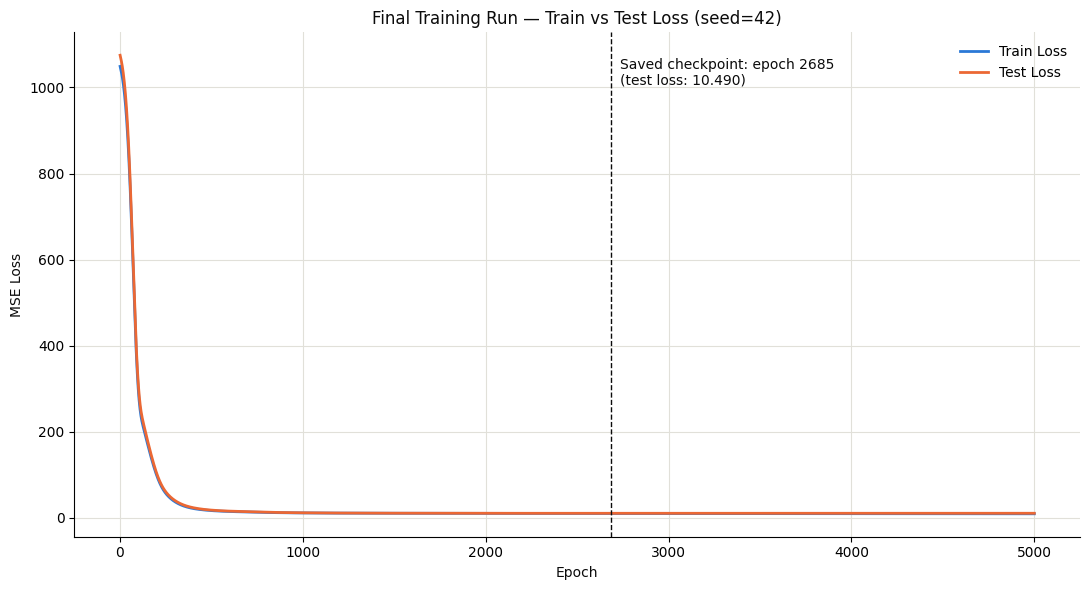

In [15]:
import matplotlib.pyplot as plt

TRAIN_COLOR  = '#2a78d6'   # blue
TEST_COLOR   = '#eb6834'   # orange
GRID_COLOR   = '#e1e0d9'
TEXT_MUTED   = '#898781'
TEXT_PRIMARY = '#0b0b0b'

fig, ax = plt.subplots(figsize=(11, 6))

epochs_range = range(1, len(train_loss_history) + 1)
ax.plot(epochs_range, train_loss_history, color=TRAIN_COLOR, linewidth=2, label='Train Loss')
ax.plot(epochs_range, test_loss_history,  color=TEST_COLOR,  linewidth=2, label='Test Loss')

# mark the checkpoint we're about to save
ax.axvline(x=best_epoch, color=TEXT_PRIMARY, linestyle='--', linewidth=1)
ax.text(best_epoch + len(train_loss_history) * 0.01, 0.95,
        f'Saved checkpoint: epoch {best_epoch}\n(test loss: {best_test_loss:.3f})',
        transform=ax.get_xaxis_transform(), ha='left', va='top',
        fontsize=10, color=TEXT_PRIMARY)

ax.set_xlabel('Epoch', color=TEXT_PRIMARY)
ax.set_ylabel('MSE Loss', color=TEXT_PRIMARY)
ax.set_title('Final Training Run — Train vs Test Loss (seed=42)', color=TEXT_PRIMARY)
ax.grid(True, color=GRID_COLOR, linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('final_loss_curve.png', dpi=150)
plt.show()

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_model = BodyFatNet(input_size=X_train_t.shape[1])
best_model.load_state_dict(best_model_state)
best_model.eval()

with torch.no_grad():
    nn_preds_t = best_model(X_test_t)

nn_preds = nn_preds_t.numpy().flatten()

mae = mean_absolute_error(y_test, nn_preds)
rmse = np.sqrt(mean_squared_error(y_test, nn_preds))
r2 = r2_score(y_test, nn_preds)

print(f"Neural Network (epoch {best_epoch}, final): MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.3f}")

Neural Network (epoch 2685, final): MAE=2.57  RMSE=3.24  R²=0.874


In [16]:
import joblib

# Save the neural network's weights
torch.save(best_model.state_dict(), f'{base}/Models/bodyfat_nn.pt')

# Save the scaler — required to preprocess any new input the same way before prediction
joblib.dump(scaler, f'{base}/Models/nn_scaler.joblib')

print("Neural network and scaler saved.")

Neural network and scaler saved.
